Epoch 1/50


C:\Users\Aniket Jadhav\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5177 - loss: 0.6878 - val_accuracy: 0.6338 - val_loss: 0.6695
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6809 - loss: 0.6341 - val_accuracy: 0.6479 - val_loss: 0.6441
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7199 - loss: 0.5925 - val_accuracy: 0.6056 - val_loss: 0.6238
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7518 - loss: 0.5553 - val_accuracy: 0.6197 - val_loss: 0.6082
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7624 - loss: 0.5229 - val_accuracy: 0.6479 - val_loss: 0.5974
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7730 - loss: 0.4943 - val_accuracy: 0.6620 - val_loss: 0.5968
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7695 - loss: 0.4700 - val_accuracy: 0.6620 - val_loss: 0.5924
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7695 - loss: 0.4502 - val_accuracy: 0.6761 - val_loss: 0.5951
Epoch 9/50
9/9 ━━━

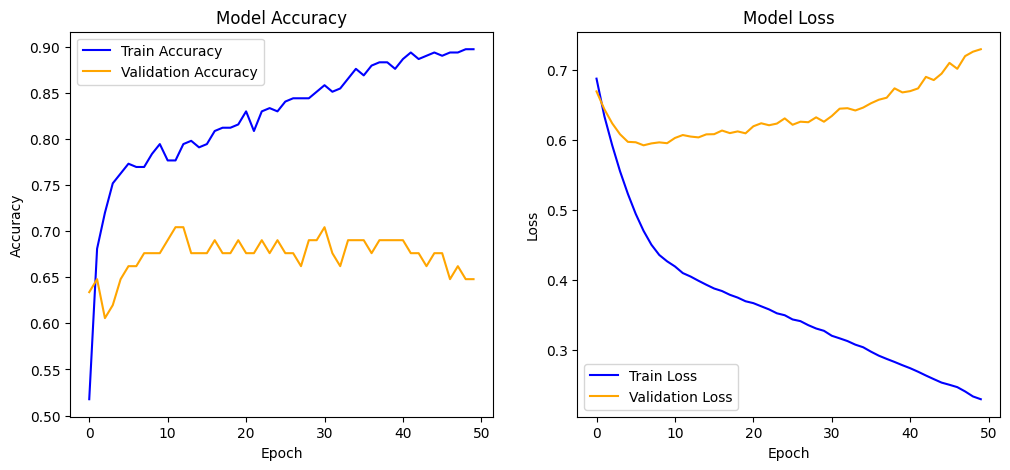

In [4]:
# Import Libraries
import numpy as np
import tensorflow as tf

# Create DNN Model
from tensorflow.keras.models import Sequential

# Add Layers
from tensorflow.keras.layers import Dense

# Split Dataset
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Load Diabetes Dataset
from sklearn.datasets import load_diabetes

# Plot Graphs
import matplotlib.pyplot as plt


# Load Dataset
data = load_diabetes()

# Input Features
X = data.data

# Convert target into Binary Classification
y = (data.target > np.median(data.target)).astype(int)


# Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Build DNN Model
model = Sequential([

    # Hidden Layer 1
    Dense(64,
          activation='relu',
          input_shape=(X_train.shape[1],)),

    # Hidden Layer 2
    Dense(32,
          activation='relu'),

    # Hidden Layer 3
    Dense(16,
          activation='relu'),

    # Output Layer
    Dense(1,
          activation='sigmoid')
])


# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# Evaluate Model
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")


# Plot Training & Validation Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy',
    color='blue'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    color='orange'
)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


# Plot Training & Validation Loss
plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Train Loss',
    color='blue'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    color='orange'
)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()